## Paquid dataset application using the `jmstate` package

In [1]:
%pip install jmstate matplotlib pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [3]:
def param_names(params_dict: dict[Any, Any]) -> list[str]:
    names: list[str] = []
    seen: set[torch.Tensor] = set()

    def _rec(node: dict[Any, Any] | torch.Tensor, prefix: list[Any]):
        if isinstance(node, torch.Tensor):
            if node in seen:
                return
            seen.add(node)

            base_name = str(prefix[0]) + "".join(f"[{item}]" for item in prefix[1:])
            num_elements = node.numel()
            if num_elements <= 1:
                names.append(base_name)
            else:
                names.extend(f"{base_name}[{i + 1}]" for i in range(num_elements))
        else:
            for k, v in node.items():
                prefix.append(k)
                _rec(v, prefix)
                prefix.pop()

    _rec(params_dict, [])

    return names

In [4]:
torch.manual_seed(42)

paquid = pd.read_csv("../data/paquid.csv")

In [5]:
def get_trajectory(id: int):
    s = (
        paquid.loc[paquid["ID"].eq(id)]
        .groupby("HIER")["age"]
        .min()
        .reindex(range(4))
        .dropna()
    )
    s = s[s >= s.cummax()]
    return [(float(a), int(k)) for k, a in s.items()]


def get_last_visit_age(id: int):
    return paquid[paquid["ID"] == id]["age"].max()


def get_t(id: int):
    return torch.tensor(paquid[paquid["ID"] == id]["age"].values)


def get_X(id: int):
    return torch.tensor(paquid.loc[paquid["ID"] == id, ["CEP", "male"]].iloc[0].values)


def get_Y(id: int):
    return torch.tensor(paquid[paquid["ID"] == id]["MMSE"].values)

In [6]:
ids = list(range(1, 501))

trajectories0 = [get_trajectory(i) for i in ids]
c0 = torch.tensor([get_last_visit_age(i) for i in ids]).view(-1, 1)
t0 = torch.nn.utils.rnn.pad_sequence(
    [get_t(i) for i in ids], batch_first=True, padding_value=torch.nan
)
y0 = torch.nn.utils.rnn.pad_sequence(
    [get_Y(i) for i in ids], batch_first=True, padding_value=torch.nan
)[..., None]
x = torch.cat([get_X(i).view(1, -1) for i in ids], dim=0)

T_MIN, T_MAX = torch.nanquantile(t0, 0).item(), torch.nanquantile(t0, 1).item()
def normalize_t(t: torch.Tensor | np.ndarray | float, inverse=False):
    if inverse:
        return (t * (T_MAX - T_MIN) + (T_MAX + T_MIN)) / 2.0
    return (2.0 * t - (T_MAX + T_MIN)) / (T_MAX - T_MIN)

Y_MIN, Y_MAX = torch.nanquantile(y0, 0).item(), torch.nanquantile(y0, 1).item()
def normalize_y(y: torch.Tensor | np.ndarray | float, inverse=False):
    if inverse:
        return (y * (Y_MAX - Y_MIN) + (Y_MAX + Y_MIN)) / 2.0
    return (2.0 * y - (Y_MAX + Y_MIN)) / (Y_MAX - Y_MIN)

y = normalize_y(y0)
trajectories = [[(normalize_t(m), s) for (m, s) in traj] for traj in trajectories0]
t = cast(torch.Tensor, normalize_t(t0))
c = normalize_t(c0)

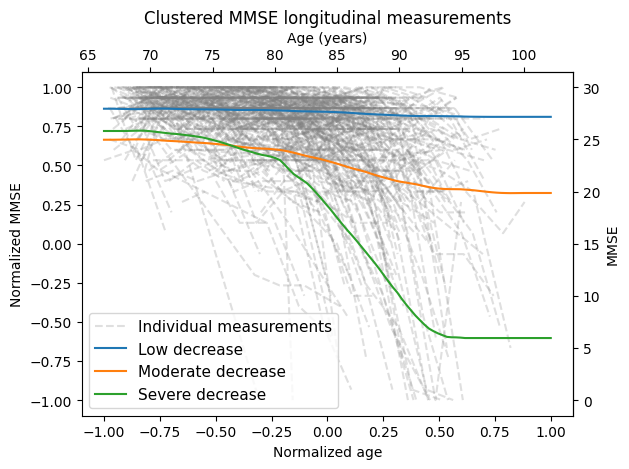

In [7]:
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer


def lerp(t: np.ndarray, y: np.ndarray, n_points: int = 100):
    grid = np.linspace(np.nanmin(t), np.nanmax(t), n_points, dtype=t.dtype)

    # Container for results
    n_curves = y.shape[0]
    Y_lerp = np.zeros((n_curves, n_points))

    for i in range(n_curves):
        mask = ~np.isnan(t[i]) & ~np.isnan(y[i])
        Xi, Yi = t[i][mask], y[i][mask]

        Y_lerp[i, :] = np.interp(grid, Xi, Yi, left=Yi[0], right=Yi[-1])

    return grid, Y_lerp


grid, Y_lerp = lerp(
    t.numpy(),
    KNNImputer().fit_transform(y.squeeze(-1).numpy()),
)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(Y_lerp)

cluster_means: list[np.ndarray] = []
for k in range(3):
    mean_curve = Y_lerp[labels == k].mean(axis=0)
    cluster_means.append(mean_curve)

final_vals = [curve[-1] for curve in cluster_means]
ordering = np.argsort(final_vals)[::-1]

names = ["Low decrease", "Moderate decrease", "Severe decrease"]
cluster_names = {ordering[i]: names[i] for i in range(3)}

plt.plot(t.T, y.squeeze(-1).T, c="gray", alpha=0.25, linestyle="--")
for name in names:
    for k in range(3):
        if cluster_names[k] == name:
            plt.plot(grid, cluster_means[k], label=name)

line = plt.Line2D([0], [0], color="gray", linestyle="--", alpha=0.25)

secax = plt.gca().secondary_xaxis(
    "top", functions=(lambda x: normalize_t(x, inverse=True), normalize_t)
)
secax.set_xlabel("Age (years)")

secay = plt.gca().secondary_yaxis(
    "right", functions=(lambda x: normalize_y(x, inverse=True), normalize_y)
)
secay.set_ylabel("MMSE")

line = plt.Line2D([0], [0], color="gray", linestyle="--", alpha=0.25)
plt.legend(
    [line] + plt.gca().get_legend_handles_labels()[0],
    ["Individual measurements"] + plt.gca().get_legend_handles_labels()[1],
    fontsize=11,
)
plt.title("Clustered MMSE longitudinal measurements")
plt.xlabel("Normalized age")
plt.ylabel("Normalized MMSE")
plt.tight_layout()
plt.savefig("../figures/paquid-mmse.pdf")
plt.show()

In [8]:
from jmstate.utils import build_buckets

buckets = build_buckets(trajectories)
print({k: v.idxs.numel() for k, v in buckets.items()})

{(0, 1): 85, (0, 2): 44, (0, 3): 11, (1, 2): 135, (1, 3): 15, (2, 3): 86}


In [9]:
def reg(t: torch.Tensor, psi: torch.Tensor):
    a, b, c = psi.chunk(3, dim=-1)
    return (a * torch.tanh((c - t) / b) + (torch.ones(1) - a)).unsqueeze(-1)

def dreg(t: torch.Tensor, psi: torch.Tensor):
    a, b, c = psi.chunk(3, dim=-1)
    return -(a * (1 - torch.tanh((c - t) / b)**2) / b).unsqueeze(-1)


def f(
    gamma: torch.Tensor | None,
    x: torch.Tensor | None,
    b: torch.Tensor,
):
    psi = cast(torch.Tensor, gamma) + b
    psi[..., 0] = psi[..., 0].sigmoid()
    psi[..., 1] = psi[..., 1].exp()
    return psi

In [10]:
from jmstate.functions import Exponential
from jmstate.typedefs import ModelDesign

surv = {key: (Exponential(1.0), dreg) for key in buckets}

model_design = ModelDesign(
    f,
    reg,
    surv,
)

In [11]:
from jmstate.typedefs import ModelData, ModelParams
from jmstate.utils import repr_from_cov
from sklearn.model_selection import train_test_split

(
    x_train,
    x_test,
    t_train,
    t_test,
    y_train,
    y_test,
    trajectories_train,
    trajectories_test,
    c_train,
    c_test,
) = train_test_split(x, t, y, trajectories, c, test_size=0.2, random_state=42)

data_train = ModelData(x_train, t_train, y_train, trajectories_train, c_train)
data_test = ModelData(x_test, t_test, y_test, trajectories_test, c_test)

In [12]:
# Will be cloned before fitting sharing same memory address
shared_beta = torch.zeros(2)
init_betas = {key: shared_beta for key in buckets} 
init_alphas = {key: torch.zeros(1) for key in buckets}

init_params = ModelParams(
    torch.zeros(3),
    repr_from_cov(torch.eye(3), method="full"),
    repr_from_cov(torch.eye(1), method="ball"),
    init_alphas,
    init_betas,
    extra=[p for val in surv.values() for p in val[0].parameters()],
)

In [13]:
from jmstate import MultiStateJointModel
from jmstate.jobs import Fit, ParamStop

model = MultiStateJointModel(model_design, init_params)
metrics = model.do(
    data_train,
    job_factories=[
        Fit(lr=0.5, fused=True),
        ParamStop(rtol=0.05),
    ],
    max_iterations=2000,
)

Running joint model:  19%|█▉        | 389/2000 [00:22<01:35, 16.92it/s]


In [14]:
# Returns the metrics for the FIM, AIC, BIC, and stores them internally
model.compute_summary()

Running joint model: 100%|██████████| 100/100 [00:07<00:00, 13.15it/s]


namespace(fim=tensor([[ 5.6420e+02,  6.0923e+02, -1.8854e+03, -5.9281e+01, -1.6861e+01,
                        2.3555e+01, -2.0299e+01,  1.3504e+01,  4.6313e+01, -2.1443e+02,
                        2.4609e+00, -5.7359e+00, -1.9190e+01, -1.0639e+02,  1.0558e+01,
                       -2.8290e+01,  8.0123e+00,  2.1179e+00],
                      [ 6.0923e+02,  7.3471e+03, -6.5486e+03, -4.9517e+02,  3.8665e+02,
                       -2.0196e+02,  1.7409e+02, -7.4364e+01, -5.9267e+01,  9.7624e+02,
                       -6.8127e+00, -1.2393e+01,  4.6225e+01,  6.3775e+02, -4.6888e+01,
                        2.7968e+02, -3.7336e+01, -1.5158e+01],
                      [-1.8854e+03, -6.5486e+03,  1.6362e+05,  1.3891e+03, -5.7726e+02,
                        1.5779e+02, -3.5370e+02,  2.6532e+02,  1.3589e+02, -9.0569e+02,
                        5.1478e+00,  1.1744e+02,  7.5965e+02,  1.7274e+02,  5.2209e+02,
                        5.9167e+02, -4.3593e+01, -3.9068e+01],
                   

In [15]:
model.summary()

╭───────────────────────────────────── Model Summary ─────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name   ┃ Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ gamma[1]         │ 2.160  │     0.047      │ 45.478  │  0.000  │        ***         │ │
│ │ gamma[2]         │ 0.159  │     0.014      │ 11.567  │  0.000  │        ***         │ │
│ │ gamma[3]         │ 1.001  │     0.003      │ 345.056 │  0.000  │        ***         │ │
│ │ Q[1]             │ -0.570 │     0.043      │ 13.124  │  0.000  │        ***         │ │
│ │ Q[2]             │ 0.957  │     0.096      │ 10.001  │  0.000  │        ***         │ │
│ │ Q[3]             │ 0.382  │     0.043      │  8.980  │  0.000  │        ***         │ │
│ │ Q[4]             │ -0.205 │     0.157      │  1.308  │  0.191  │                    │ │
│ │ Q[5]             │ -2.331 │     0.138      │ 16.903  │  0.000  │        ***         │ │
│ │ Q[6]             │ 0.522  │     0.047      │ 11.138  │  0.000  │        ***         │ │
│ │ R                │ 2.083  │     0.026      │ 78.978  │  0.000  │        ***         │ │
│ │ alphas[(0, 1)]   │ 0.722  │     0.715      │  1.010  │  0.312  │                    │ │
│ │ alphas[(0, 2)]   │ -0.540 │     0.403      │  1.340  │  0.180  │                    │ │
│ │ alphas[(0, 3)]   │ -1.003 │     0.200      │  5.011  │  0.000  │        ***         │ │
│ │ alphas[(1, 2)]   │ -0.121 │     0.038      │  3.190  │  0.001  │         **         │ │
│ │ alphas[(1, 3)]   │ -0.048 │     0.252      │  0.189  │  0.850  │                    │ │
│ │ alphas[(2, 3)]   │ -0.307 │     0.074      │  4.144  │  0.000  │        ***         │ │
│ │ betas[(0, 1)][1] │ -0.299 │     0.913      │  0.328  │  0.743  │                    │ │
│ │ betas[(0, 1)][2] │ 0.097  │     1.030      │  0.094  │  0.925  │                    │ │
│ └──────────────────┴────────┴────────────────┴─────────┴─────────┴────────────────────┘ │
│ ─────────────────────────────────────────────────────────────────────────────────────── │
│ Log-likelihood: 1033.855                                                                │
│ Penalized negative log-likelihood: -1033.855                                            │
│ AIC: -2031.711                                                                          │
│ BIC: -1930.188                                                                          │
│ ─────────────────────────────────────────────────────────────────────────────────────── │
╰─────────────────────────────────────────────────────────────────────────────────────────╯

In [17]:
from dataclasses import replace

from jmstate.jobs import PredictTrajectories


def predict_trunc(trunc_time: float):
    trajectories_trunc = [
        [(t, s) for i, (t, s) in enumerate(trajectory) if t <= trunc_time or i == 0]
        for trajectory in data_test.trajectories
    ]
    c = torch.tensor([trajectory[-1][0] for trajectory in data_test.trajectories]).view(
        -1, 1
    )

    trunc_y = data_test.y.clone()
    trunc_y[data_test.t > trunc_time] = torch.nan
    data_test_trunc = replace(
        data_test,
        y=trunc_y,
        trajectories=trajectories_trunc,
        c=torch.maximum(c, trunc_time),
    )

    return model.do(
        data_test_trunc,
        job_factories=[PredictTrajectories(c_max=data_test.c)],
        max_iterations=10,
    ).pred_trajectories


def hier_probs(
    pred_trajectories: list[list[list[tuple[float, Any]]]],
    u: torch.Tensor,
):
    counts = torch.zeros(len(pred_trajectories[0]), 4)
    num_sets = len(pred_trajectories)

    for trajectories in pred_trajectories:
        for i, trajectory in enumerate(trajectories):
            last_valid_state = trajectory[0][1]

            for t, s in reversed(trajectory):
                if t <= u:
                    last_valid_state = s
                    break

            counts[i][last_valid_state] += 1

    return counts / num_sets

Running joint model: 100%|██████████| 10/10 [00:04<00:00,  2.47it/s]


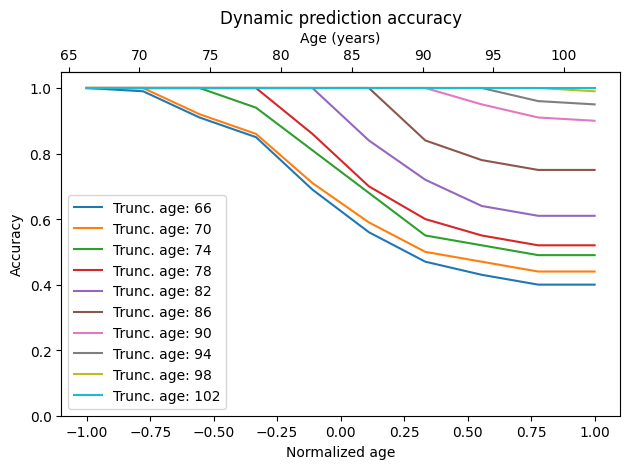

In [18]:
trunc_times = torch.linspace(-1, 1, 10)
us = torch.linspace(-1, 1, 10)

for trunc_time in trunc_times:
    pred_trajectories = predict_trunc(trunc_time)

    pred_probs = [hier_probs(pred_trajectories, u) for u in us]
    real_states = [hier_probs([data_test.trajectories], u) for u in us]

    accuracy = [
        (real_state.argmax(dim=-1) == pred_prob.argmax(dim=-1)).float().mean()
        for real_state, pred_prob in zip(real_states, pred_probs, strict=True)
    ]

    plt.plot(us, accuracy, label=f"Trunc. age: {int(normalize_t(trunc_time.item(), inverse=True))}")

secax = plt.gca().secondary_xaxis("top", functions=(lambda x: normalize_t(x, inverse=True), normalize_t))
secax.set_xlabel("Age (years)")

plt.ylim(0, 1.05)
plt.title("Dynamic prediction accuracy")
plt.xlabel("Normalized age")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/paquid-accuracy.pdf")
plt.show()